# Robust Recourse Under Missingness

## Setup

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from data        import load_diabetes, train_test_split, MUTABLE_COLS
from model       import train, compute_hessian, predict, score
from imputer     import fit_mice, get_imputation_params, calibrate_rho
from beam_search import beam_search
from evaluate    import nominal_validity, model_retrain_validity, awp_validity, lof_plausibility, print_recourse_summary

%matplotlib inline

## Data

In [32]:
X, Xi, y, Phi, feature_names, col_means, col_stds = load_diabetes()
train_idx, test_idx = train_test_split(len(y))

X_train, Xi_train = X[train_idx], Xi[train_idx]
X_test,  Xi_test  = X[test_idx],  Xi[test_idx]
Phi_train, y_train = Phi[train_idx], y[train_idx]
Phi_test,  y_test  = Phi[test_idx],  y[test_idx]

n=768  d=8  diabetic=268  not=500
  Glucose                          5 missing (0.7%)
  BloodPressure                   35 missing (4.6%)
  SkinThickness                  227 missing (29.6%)
  Insulin                        374 missing (48.7%)
  BMI                             11 missing (1.4%)


## Model

In [33]:
theta_hat, model = train(Phi_train, y_train)
hessian_matrix   = compute_hessian(Phi_train, theta_hat)

train_acc = (predict(Phi_train, theta_hat) == y_train).mean()
test_acc  = (predict(Phi_test,  theta_hat) == y_test).mean()
print(f"train acc: {train_acc:.3f}  test acc: {test_acc:.3f}")
print(f"hessian min eigenvalue: {np.linalg.eigvalsh(hessian_matrix).min():.6f}")

train acc: 0.774  test acc: 0.765
hessian min eigenvalue: 0.001000


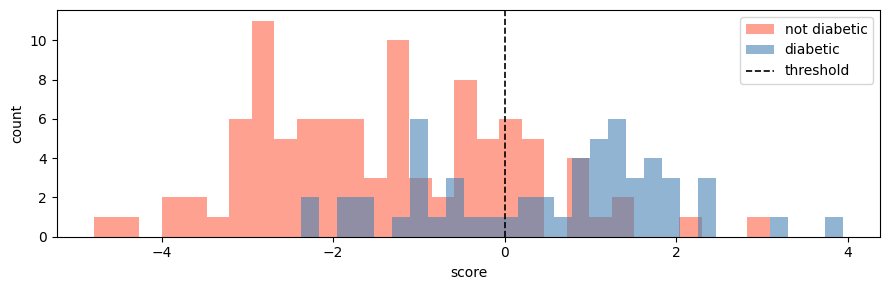

In [34]:
# score distribution by class
test_scores = score(Phi_test, theta_hat)

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(test_scores[y_test == -1], bins=30, alpha=0.6, color='tomato',    label='not diabetic')
ax.hist(test_scores[y_test ==  1], bins=30, alpha=0.6, color='steelblue', label='diabetic')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='threshold')
ax.set_xlabel("score")
ax.set_ylabel("count")
ax.legend()
plt.tight_layout()
plt.show()

## Imputer

In [35]:
mice_imputer = fit_mice(X_train, Xi_train)

## Pick a denied person

In [36]:
test_preds   = predict(Phi_test, theta_hat)
denied_idx   = test_idx[test_preds == -1]

# find a denied person with missing features
denied_with_missing = [i for i in denied_idx if Xi[i].sum() > 0]
person_idx = denied_with_missing[0]

x0   = X[person_idx]
xi0  = Xi[person_idx]
raw_score = score(Phi[[person_idx]], theta_hat)[0]

print(f"person {person_idx}  |  score: {raw_score:.4f}  (needs >= 0)")
print(f"missing: {[feature_names[j] for j in np.where(xi0 == 1)[0]] or 'none'}")
print()
for j, name in enumerate(feature_names):
    status = ' [missing]' if xi0[j] == 1 else ''
    print(f"  {name:<30} {x0[j]:>7.3f}{status}")

person 324  |  score: -1.3468  (needs >= 0)
missing: ['Insulin']

  Pregnancies                     -0.548
  Glucose                         -0.317
  BloodPressure                    0.210
  SkinThickness                    0.272
  Insulin                          0.000 [missing]
  BMI                              0.469
  DiabetesPedigreeFunction        -0.978
  Age                             -1.042


## Recourse

In [37]:
# hyperparameters
epsilon         = 0.001   # rashomon radius — optimization tolerance
epsilon_eval    = 0.01    # evaluation tolerance — for stress test
rho_coverage    = 0.90    # fraction of MICE draws the optimization ellipsoid covers
stress_coverage = 0.99    # fraction of MICE draws the stress-test ellipsoid covers
kappa_val       = 0.5
delta_max       = 2.0
beam_width      = 3
K_max           = 3
K_mice          = 100

kappa  = np.ones(len(x0)) * kappa_val
J_edit = MUTABLE_COLS          # exclude immutable features: Pregnancies, DPF, Age
x_min  = x0 - delta_max
x_max  = x0 + delta_max

In [38]:
best_r, best_delta, best_cost, history, best_mu, best_Sigma, best_draws, best_rho_opt = beam_search(
    x0, xi0,
    theta_hat, hessian_matrix,
    mice_imputer,
    epsilon      = epsilon,
    rho_coverage = rho_coverage,
    kappa        = kappa,
    J_edit       = J_edit,
    tau          = 0.0,
    beam_width   = beam_width,
    K_max        = K_max,
    K_mice       = K_mice,
    x_min        = x_min,
    x_max        = x_max,
    verbose      = True,
)


step 0: 1 candidate(s)
  r=[0, 0, 0, 0, 0, 0, 0, 0]  cost=1.6224

step 1: 1 candidate(s)
  r=[0, 0, 0, 0, 1, 0, 0, 0]  cost=2.1453
no more features to reveal


## Result

In [39]:
if best_r is None:
    print("no feasible recourse found — try increasing K_max or decreasing epsilon")
else:
    print(f"total cost: {best_cost:.4f}")
    print(f"reveal    : {[feature_names[j] for j in np.where(best_r == 1)[0]] or 'nothing'}")
    print()
    print(f"{'feature':<30} {'from':>8} {'to':>8} {'change':>8}")
    print('-' * 56)
    for j in range(len(x0)):
        if abs(best_delta[j]) > 1e-4:
            old, new = x0[j], x0[j] + best_delta[j]
            print(f"{feature_names[j]:<30} {old:>8.3f} {new:>8.3f} {new-old:>+8.3f}")

total cost: 1.6224
reveal    : nothing

feature                            from       to   change
--------------------------------------------------------
Glucose                          -0.317    1.060   +1.378
BloodPressure                     0.210   -0.005   -0.215
SkinThickness                     0.272    0.400   +0.128
BMI                               0.469    1.288   +0.819


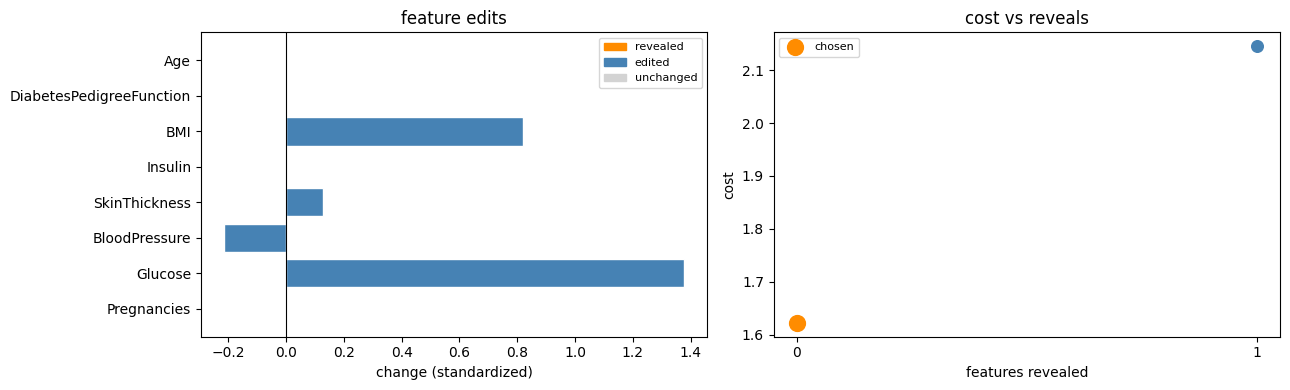

In [40]:
if best_r is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # feature changes
    ax = axes[0]
    colors = ['darkorange' if best_r[j] == 1
              else 'steelblue' if abs(best_delta[j]) > 1e-4
              else 'lightgrey'
              for j in range(len(feature_names))]
    ax.barh(feature_names, best_delta, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel("change (standardized)")
    ax.set_title("feature edits")
    ax.legend(handles=[
        mpatches.Patch(color='darkorange', label='revealed'),
        mpatches.Patch(color='steelblue',  label='edited'),
        mpatches.Patch(color='lightgrey',  label='unchanged'),
    ], fontsize=8)

    # cost vs reveals
    ax2 = axes[1]
    feasible = [h for h in history if h['feasible']]
    if feasible:
        n_reveals = [int(h['r'].sum()) for h in feasible]
        costs     = [h['cost'] for h in feasible]
        ax2.scatter(n_reveals, costs, s=70, color='steelblue', zorder=3)
        ax2.scatter([int(best_r.sum())], [best_cost], s=130, color='darkorange',
                    zorder=4, label='chosen')
        ax2.set_xlabel("features revealed")
        ax2.set_ylabel("cost")
        ax2.set_title("cost vs reveals")
        ax2.set_xticks(sorted(set(n_reveals)))
        ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## Sensitivity to epsilon

epsilon=0.0001  cost=1.2951
epsilon=0.0005  cost=1.5098
epsilon=0.0010  cost=1.6764
epsilon=0.0050  cost=2.4706
epsilon=0.0100  cost=2.9046
epsilon=0.0500  infeasible


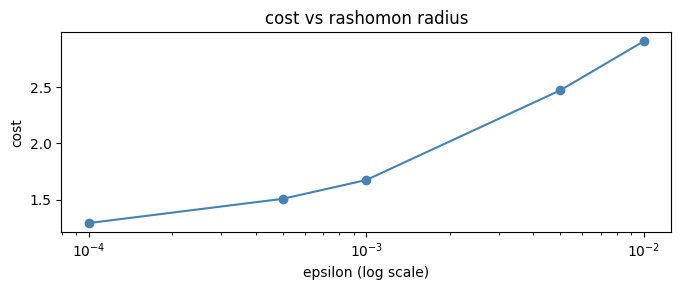

In [41]:
epsilons = [1e-4, 5e-4, 0.001, 0.005, 0.01, 0.05]
costs    = []

for eps in epsilons:
    _, _, cost, _, _, _, _, _ = beam_search(
        x0, xi0, theta_hat, hessian_matrix, mice_imputer,
        epsilon=eps, rho_coverage=rho_coverage, kappa=kappa, J_edit=J_edit,
        tau=0.0, beam_width=3, K_max=3, K_mice=50,
        x_min=x_min, x_max=x_max,
        verbose=False,
    )
    costs.append(cost)
    status = f"cost={cost:.4f}" if cost < np.inf else "infeasible"
    print(f"epsilon={eps:.4f}  {status}")

fig, ax = plt.subplots(figsize=(7, 3))
feasible_eps   = [e for e, c in zip(epsilons, costs) if c < np.inf]
feasible_costs = [c for c in costs if c < np.inf]
ax.plot(feasible_eps, feasible_costs, 'o-', color='steelblue')
ax.set_xscale('log')
ax.set_xlabel("epsilon (log scale)")
ax.set_ylabel("cost")
ax.set_title("cost vs rashomon radius")
plt.tight_layout()
plt.show()

## Evaluation

In [42]:
# single-person evaluation (uses the person from the Recourse section above)
if best_r is not None:
    rho_stress = calibrate_rho(best_draws, best_mu, best_Sigma, stress_coverage)

    nom = nominal_validity(theta_hat, x0, best_delta, xi0, best_r, best_mu)
    rr = model_retrain_validity(
        X_train, Xi_train, y_train,
        x0, best_delta, xi0, best_r, best_mu,
        n_models=50,
    )
    awp_sanity, lb_sanity = awp_validity(
        theta_hat, hessian_matrix,
        x0, best_delta, xi0, best_r, best_mu, best_Sigma,
        epsilon_eval=epsilon, rho_eval=best_rho_opt,
    )
    awp_stress, lb_stress = awp_validity(
        theta_hat, hessian_matrix,
        x0, best_delta, xi0, best_r, best_mu, best_Sigma,
        epsilon_eval=epsilon_eval, rho_eval=rho_stress,
    )
    lof = lof_plausibility(
        X_train, Xi_train, mice_imputer,
        x0, best_delta, xi0, best_r, best_mu,
    )

    print(f"person {person_idx}  |  recourse cost: {best_cost:.4f}")
    print(f"  nominal validity          : {nom}")
    print(f"  model retrain validity    : {rr:.3f}  (50 bootstrap retrains)")
    print(f"  awp sanity  eps={epsilon}  rho={best_rho_opt:.2f}  : {awp_sanity}  lb={lb_sanity:.4f}")
    print(f"  awp stress  eps={epsilon_eval}  rho={rho_stress:.2f}  : {awp_stress}  lb={lb_stress:.4f}")
    print(f"  lof plausibility          : {lof:.4f}  (1.0 = perfectly in-distribution)")
else:
    print("no feasible recourse — skip evaluation")

person 324  |  recourse cost: 1.6224
  nominal validity          : True
  model retrain validity    : 1.000  (50 bootstrap retrains)
  awp sanity  eps=0.001  rho=1.52  : True  lb=0.0000
  awp stress  eps=0.01  rho=2.32  : False  lb=-1.9614
  lof plausibility          : 1.0836  (1.0 = perfectly in-distribution)


### Qualitative Case Studies

In [43]:
denied_with_missing = [
    i for i in test_idx
    if predict(Phi[[i]], theta_hat)[0] == -1 and Xi[i].sum() > 0
]

for case_num, person_idx_q in enumerate(denied_with_missing[:3]):
    x0_q, xi0_q = X[person_idx_q], Xi[person_idx_q]
    missing_names = [feature_names[j] for j in np.where(xi0_q == 1)[0]]
    print(f"\n{'='*80}")
    print(f"Case {case_num+1}  (person {person_idx_q})  missing: {missing_names}")
    print(f"{'='*80}")

    r_q, delta_q, cost_q, _, mu_q, Sigma_q, draws_q, rho_opt_q = beam_search(
        x0_q, xi0_q, theta_hat, hessian_matrix, mice_imputer,
        epsilon=epsilon, rho_coverage=rho_coverage, kappa=kappa, J_edit=J_edit,
        x_min=x0_q - delta_max, x_max=x0_q + delta_max,
        verbose=False,
    )

    if r_q is None:
        print("no feasible recourse found")
        continue

    rho_stress_q      = calibrate_rho(draws_q, mu_q, Sigma_q, stress_coverage)
    nom_q             = nominal_validity(theta_hat, x0_q, delta_q, xi0_q, r_q, mu_q)
    rr_q              = model_retrain_validity(
        X_train, Xi_train, y_train,
        x0_q, delta_q, xi0_q, r_q, mu_q, n_models=50,
    )
    awp_sanity_q, lb_sanity_q = awp_validity(
        theta_hat, hessian_matrix,
        x0_q, delta_q, xi0_q, r_q, mu_q, Sigma_q,
        epsilon_eval=epsilon, rho_eval=rho_opt_q,
    )
    awp_stress_q, lb_stress_q = awp_validity(
        theta_hat, hessian_matrix,
        x0_q, delta_q, xi0_q, r_q, mu_q, Sigma_q,
        epsilon_eval=epsilon_eval, rho_eval=rho_stress_q,
    )
    lof_q = lof_plausibility(
        X_train, Xi_train, mice_imputer,
        x0_q, delta_q, xi0_q, r_q, mu_q,
    )

    metrics_q = {
        "total_cost": cost_q,
        "nominal":    nom_q,
        "retrain":    rr_q,
        "awp_sanity": awp_sanity_q, "lb_sanity": lb_sanity_q,
        "awp_stress": awp_stress_q, "lb_stress": lb_stress_q,
        "lof":        lof_q,
    }
    print_recourse_summary(
        x0_q, xi0_q, r_q, delta_q, col_means, col_stds, feature_names,
        kappa=kappa, metrics=metrics_q,
    )


Case 1  (person 324)  missing: ['Insulin']
--------------------------------------------------------------------------------
Feature                       Original  Miss  Reveal  Post-Action      Change
--------------------------------------------------------------------------------
Pregnancies                       2.00    no       -         2.00           -
Glucose                         112.00    no       -       154.05      +42.05
BloodPressure                    75.00    no       -        72.34       -2.66
SkinThickness                    32.00    no       -        33.34       +1.34
Insulin                            ---   yes       -          ---           -
BMI                              35.70    no       -        41.37       +5.67
DiabetesPedigreeFunction          0.15    no       -         0.15           -
Age                              21.00    no       -        21.00           -
--------------------------------------------------------------------------------
  cost     

### Batch evaluation — all denied test persons with missing features

denied test persons with missing features: 53

feasibility rate : 51/53 = 0.962
nominal validity : 1.000  (51/51 pass)
model retrain    : mean=0.990  min=0.960  max=1.000
awp sanity       : 0.686  (35/51 pass)
awp stress       : 0.000  (0/51 pass)
lof plausibility : mean=1.129  min=1.002  max=1.339
reveals          : 7/51 cases used at least 1 reveal


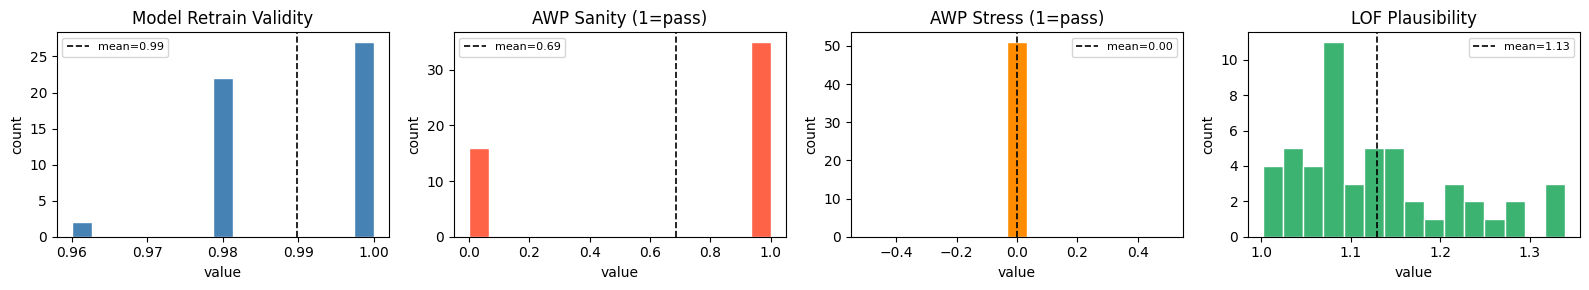

In [44]:
batch_results = []

denied_all = [i for i in test_idx if predict(Phi[[i]], theta_hat)[0] == -1 and Xi[i].sum() > 0]
print(f"denied test persons with missing features: {len(denied_all)}")

for idx in denied_all:
    x0_b, xi0_b = X[idx], Xi[idx]

    r_b, delta_b, cost_b, _, mu_b, Sigma_b, draws_b, rho_opt_b = beam_search(
        x0_b, xi0_b,
        theta_hat, hessian_matrix,
        mice_imputer,
        epsilon      = epsilon,
        rho_coverage = rho_coverage,
        kappa        = kappa,
        J_edit       = J_edit,
        tau          = 0.0,
        beam_width   = beam_width,
        K_max        = K_max,
        K_mice       = K_mice,
        x_min        = x0_b - delta_max,
        x_max        = x0_b + delta_max,
        verbose      = False,
    )

    if r_b is None:
        batch_results.append({"idx": idx, "feasible": False, "nom": None, "rr": None,
                              "awp": None, "awp_stress": None, "lof": None})
        continue

    rho_stress_b = calibrate_rho(draws_b, mu_b, Sigma_b, stress_coverage)

    nom_b = nominal_validity(theta_hat, x0_b, delta_b, xi0_b, r_b, mu_b)
    rr_b  = model_retrain_validity(
        X_train, Xi_train, y_train,
        x0_b, delta_b, xi0_b, r_b, mu_b, n_models=50,
    )
    awp_b, _ = awp_validity(
        theta_hat, hessian_matrix,
        x0_b, delta_b, xi0_b, r_b, mu_b, Sigma_b,
        epsilon_eval=epsilon, rho_eval=rho_opt_b,
    )
    awp_stress_b, _ = awp_validity(
        theta_hat, hessian_matrix,
        x0_b, delta_b, xi0_b, r_b, mu_b, Sigma_b,
        epsilon_eval=epsilon_eval, rho_eval=rho_stress_b,
    )
    lof_b = lof_plausibility(
        X_train, Xi_train, mice_imputer,
        x0_b, delta_b, xi0_b, r_b, mu_b,
    )

    n_revealed = int(r_b.sum())
    batch_results.append({"idx": idx, "feasible": True, "cost": cost_b, "nom": nom_b,
                          "rr": rr_b, "awp": awp_b, "awp_stress": awp_stress_b,
                          "lof": lof_b, "n_revealed": n_revealed})

# ── summary ──────────────────────────────────────────────────────────────────
feasible = [r for r in batch_results if r["feasible"]]
n_total  = len(batch_results)
n_feas   = len(feasible)

print(f"\nfeasibility rate : {n_feas}/{n_total} = {n_feas/n_total:.3f}")

if n_feas > 0:
    nom_vals        = [r["nom"]        for r in feasible]
    rr_vals         = [r["rr"]         for r in feasible]
    awp_vals        = [r["awp"]        for r in feasible]
    awp_stress_vals = [r["awp_stress"] for r in feasible]
    lof_vals        = [r["lof"]        for r in feasible]
    reveal_counts   = [r["n_revealed"] for r in feasible]

    print(f"nominal validity : {np.mean(nom_vals):.3f}  ({sum(nom_vals)}/{n_feas} pass)")
    print(f"model retrain    : mean={np.mean(rr_vals):.3f}  min={np.min(rr_vals):.3f}  max={np.max(rr_vals):.3f}")
    print(f"awp sanity       : {np.mean(awp_vals):.3f}  ({sum(awp_vals)}/{n_feas} pass)")
    print(f"awp stress       : {np.mean(awp_stress_vals):.3f}  ({sum(awp_stress_vals)}/{n_feas} pass)")
    print(f"lof plausibility : mean={np.mean(lof_vals):.3f}  min={np.min(lof_vals):.3f}  max={np.max(lof_vals):.3f}")
    print(f"reveals          : {sum(r > 0 for r in reveal_counts)}/{n_feas} cases used at least 1 reveal")

    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    for ax, vals, title, color in zip(
        axes,
        [rr_vals, [float(v) for v in awp_vals], [float(v) for v in awp_stress_vals], lof_vals],
        ["Model Retrain Validity", "AWP Sanity (1=pass)", "AWP Stress (1=pass)", "LOF Plausibility"],
        ["steelblue", "tomato", "darkorange", "mediumseagreen"],
    ):
        ax.hist(vals, bins=15, color=color, edgecolor='white')
        ax.axvline(np.mean(vals), color='black', linestyle='--', linewidth=1.2,
                   label=f"mean={np.mean(vals):.2f}")
        ax.set_title(title)
        ax.set_xlabel("value")
        ax.set_ylabel("count")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

                                     ours baseline (eps=0)
feasibility rate                    0.962            1.000
model retrain validity (mean)       0.990            0.718
awp sanity pass rate                0.686            0.000
awp stress pass rate                0.000            0.000


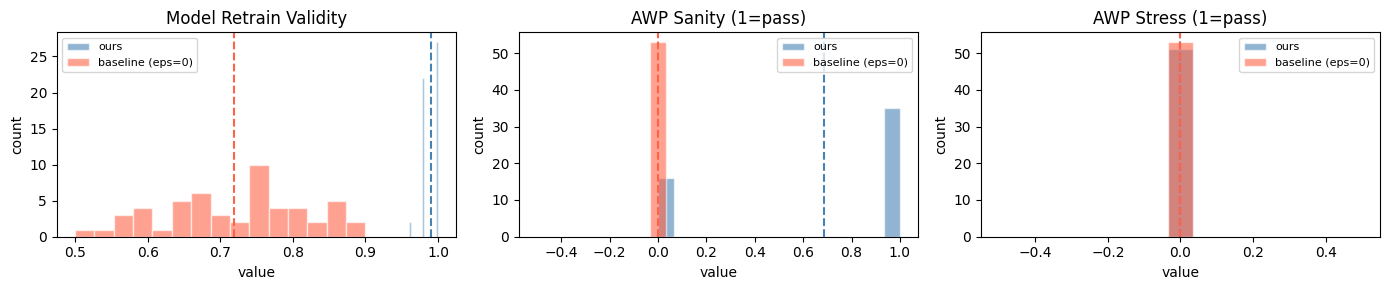

In [45]:
baseline_results = []

for idx in denied_all:
    x0_b, xi0_b = X[idx], Xi[idx]

    r_b, delta_b, cost_b, _, mu_b, Sigma_b, draws_b, rho_opt_b = beam_search(
        x0_b, xi0_b,
        theta_hat, hessian_matrix,
        mice_imputer,
        epsilon      = 0.0,
        rho_coverage = rho_coverage,
        kappa        = kappa,
        J_edit       = J_edit,
        tau          = 0.0,
        beam_width   = beam_width,
        K_max        = K_max,
        K_mice       = K_mice,
        x_min        = x0_b - delta_max,
        x_max        = x0_b + delta_max,
        verbose      = False,
    )

    if r_b is None:
        baseline_results.append({"idx": idx, "feasible": False, "rr": None,
                                  "awp": None, "awp_stress": None})
        continue

    rho_stress_b = calibrate_rho(draws_b, mu_b, Sigma_b, stress_coverage)

    rr_b = model_retrain_validity(
        X_train, Xi_train, y_train,
        x0_b, delta_b, xi0_b, r_b, mu_b, n_models=50,
    )
    awp_b, _ = awp_validity(
        theta_hat, hessian_matrix,
        x0_b, delta_b, xi0_b, r_b, mu_b, Sigma_b,
        epsilon_eval=epsilon, rho_eval=rho_opt_b,
    )
    awp_stress_b, _ = awp_validity(
        theta_hat, hessian_matrix,
        x0_b, delta_b, xi0_b, r_b, mu_b, Sigma_b,
        epsilon_eval=epsilon_eval, rho_eval=rho_stress_b,
    )

    baseline_results.append({"idx": idx, "feasible": True, "cost": cost_b,
                              "rr": rr_b, "awp": awp_b, "awp_stress": awp_stress_b})

# ── comparison summary ────────────────────────────────────────────────────────
b_feasible = [r for r in baseline_results if r["feasible"]]
n_b        = len(b_feasible)

ours_rr     = [r["rr"]         for r in feasible]
ours_awp    = [r["awp"]        for r in feasible]
ours_awp_st = [r["awp_stress"] for r in feasible]
base_rr     = [r["rr"]         for r in b_feasible]
base_awp    = [r["awp"]        for r in b_feasible]
base_awp_st = [r["awp_stress"] for r in b_feasible]

print(f"{'':30s} {'ours':>10s} {'baseline (eps=0)':>16s}")
print(f"{'feasibility rate':30s} {len(feasible)/len(batch_results):>10.3f} {n_b/len(baseline_results):>16.3f}")
print(f"{'model retrain validity (mean)':30s} {np.mean(ours_rr):>10.3f} {np.mean(base_rr):>16.3f}")
print(f"{'awp sanity pass rate':30s} {np.mean(ours_awp):>10.3f} {np.mean(base_awp):>16.3f}")
print(f"{'awp stress pass rate':30s} {np.mean(ours_awp_st):>10.3f} {np.mean(base_awp_st):>16.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, o_vals, b_vals, title in zip(
    axes,
    [ours_rr, [float(v) for v in ours_awp], [float(v) for v in ours_awp_st]],
    [base_rr, [float(v) for v in base_awp], [float(v) for v in base_awp_st]],
    ["Model Retrain Validity", "AWP Sanity (1=pass)", "AWP Stress (1=pass)"],
):
    ax.hist(o_vals, bins=15, alpha=0.6, color='steelblue', label='ours', edgecolor='white')
    ax.hist(b_vals, bins=15, alpha=0.6, color='tomato',    label='baseline (eps=0)', edgecolor='white')
    ax.axvline(np.mean(o_vals), color='steelblue', linestyle='--', linewidth=1.5)
    ax.axvline(np.mean(b_vals), color='tomato',    linestyle='--', linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()